<a href="https://colab.research.google.com/github/mounapriya0606-byte/Dissertation/blob/main/Dissertation_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Import required libraries
import pandas as pd

# Step 2: Load the dataset
df = pd.read_csv("all_tickets_processed_improved_v3.csv")

# Step 3: View basic info
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (47837, 2)


,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


In [ ]:
# Check column names
print(df.columns)

# Check data types and null values
df.info()

# Check for missing values
print(df.isnull().sum())

Index(['Document', 'Topic_group'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47837 entries, 0 to 47836
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Document     47837 non-null  object
 1   Topic_group  47837 non-null  object
dtypes: object(2)
memory usage: 747.6+ KB
Document       0
Topic_group    0
dtype: int64


In [ ]:
# Count of each category
df['Topic_group'].value_counts()

,count
Topic_group,
Hardware,13617
HR Support,10915
Access,7125
Miscellaneous,7060
Storage,2777
Purchase,2464
Internal Project,2119
Administrative rights,1760


Data Cleaning

In [ ]:
# Remove duplicate rows
df = df.drop_duplicates()

# Check new shape
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (47837, 2)


In [ ]:
# Check missing values again
print(df.isnull().sum())

# Drop rows with missing text or label
df = df.dropna(subset=['Document', 'Topic_group'])

# Confirm
print("Shape after removing nulls:", df.shape)

Document       0
Topic_group    0
dtype: int64
Shape after removing nulls: (47837, 2)


In [ ]:
import re

def clean_text(text):
    text = str(text).lower()  # lowercase
    text = re.sub(r'\n', ' ', text)  # remove newlines
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)  # remove special chars
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
    return text

# Apply cleaning
df['cleaned_text'] = df['Document'].apply(clean_text)

# Preview
df[['Document', 'cleaned_text']].head()

,Document,cleaned_text
0,connection with icon icon dear please setup ic...,connection with icon icon dear please setup ic...
1,work experience user work experience user hi w...,work experience user work experience user hi w...
2,requesting for meeting requesting meeting hi p...,requesting for meeting requesting meeting hi p...
3,reset passwords for external accounts re expir...,reset passwords for external accounts re expir...
4,mail verification warning hi has got attached ...,mail verification warning hi has got attached ...


Text Preprocessing

In [ ]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
def preprocess_text(text):
    tokens = word_tokenize(text)  # Tokenization

    tokens = [word for word in tokens if word not in stop_words]  # Remove stopwords

    tokens = [lemmatizer.lemmatize(word) for word in tokens]  # Lemmatization

    return " ".join(tokens)

In [ ]:
df['processed_text'] = df['cleaned_text'].apply(preprocess_text)

# Preview
df[['cleaned_text', 'processed_text']].head()

,cleaned_text,processed_text
0,connection with icon icon dear please setup ic...,connection icon icon dear please setup icon pe...
1,work experience user work experience user hi w...,work experience user work experience user hi w...
2,requesting for meeting requesting meeting hi p...,requesting meeting requesting meeting hi pleas...
3,reset passwords for external accounts re expir...,reset password external account expire day hi ...
4,mail verification warning hi has got attached ...,mail verification warning hi got attached plea...


Data Splitting + Dataset Preparation

In [ ]:
from sklearn.model_selection import train_test_split

# Features and labels
X = df['processed_text']
y = df['Topic_group']

# Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (38269,)
Testing size: (9568,)


In [ ]:
# Real dataset (original)
real_train = X_train.copy()
real_labels = y_train.copy()

In [ ]:
import random
from nltk.corpus import wordnet

def synonym_replacement(text):
    words = text.split()

    if len(words) < 3:
        return text

    word_to_replace = random.choice(words)

    synonyms = wordnet.synsets(word_to_replace)

    if synonyms:
        synonym_words = [lemma.name() for syn in synonyms for lemma in syn.lemmas()]
        if synonym_words:
            new_word = random.choice(synonym_words)
            words = [new_word if word == word_to_replace else word for word in words]

    return " ".join(words)

# Apply to create synthetic data
synthetic_train = real_train.apply(synonym_replacement)
synthetic_labels = real_labels.copy()

In [ ]:
# Combine real + synthetic
combined_train = pd.concat([real_train, synthetic_train])
combined_labels = pd.concat([real_labels, synthetic_labels])

print("Combined dataset size:", combined_train.shape)

Combined dataset size: (76538,)


Feature Extraction (TF-IDF)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,   # limit features (important for performance)
    ngram_range=(1,2)    # use unigrams + bigrams
)

In [ ]:
# Fit on training data only (VERY IMPORTANT)
X_train_real_tfidf = tfidf.fit_transform(real_train)

# Transform test data
X_test_tfidf = tfidf.transform(X_test)

print("Real Train Shape:", X_train_real_tfidf.shape)
print("Test Shape:", X_test_tfidf.shape)

Real Train Shape: (38269, 5000)
Test Shape: (9568, 5000)


In [ ]:
X_train_synth_tfidf = tfidf.transform(synthetic_train)

print("Synthetic Train Shape:", X_train_synth_tfidf.shape)

Synthetic Train Shape: (38269, 5000)


In [ ]:
X_train_combined_tfidf = tfidf.transform(combined_train)

print("Combined Train Shape:", X_train_combined_tfidf.shape)

Combined Train Shape: (76538, 5000)


EDA (Exploratory Data Analysis)

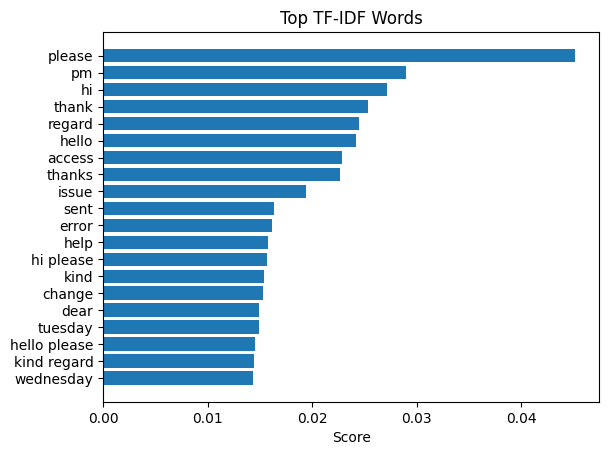

In [ ]:
import numpy as np

# Get feature names
feature_names = tfidf.get_feature_names_out()

# Get top words based on mean TF-IDF score
mean_tfidf = np.mean(X_train_real_tfidf.toarray(), axis=0)

top_indices = mean_tfidf.argsort()[-20:]

top_words = [feature_names[i] for i in top_indices]
top_scores = mean_tfidf[top_indices]

# Plot
import matplotlib.pyplot as plt

plt.figure()
plt.barh(top_words, top_scores)
plt.title("Top TF-IDF Words")
plt.xlabel("Score")

plt.show()

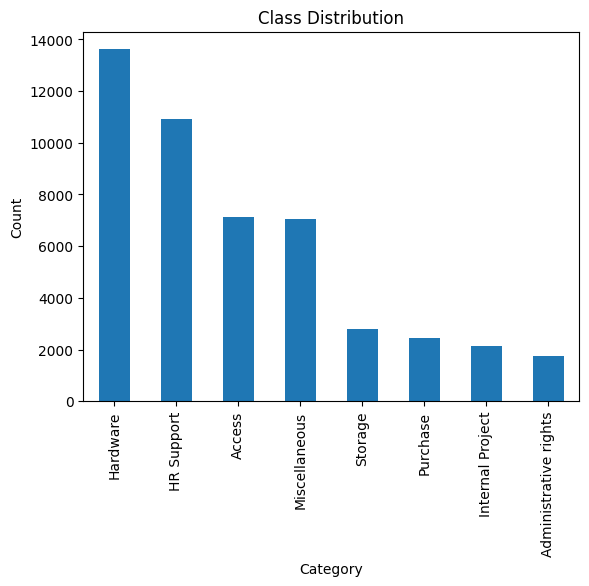

In [ ]:
df['Topic_group'].value_counts().plot(kind='bar')

plt.title("Class Distribution")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

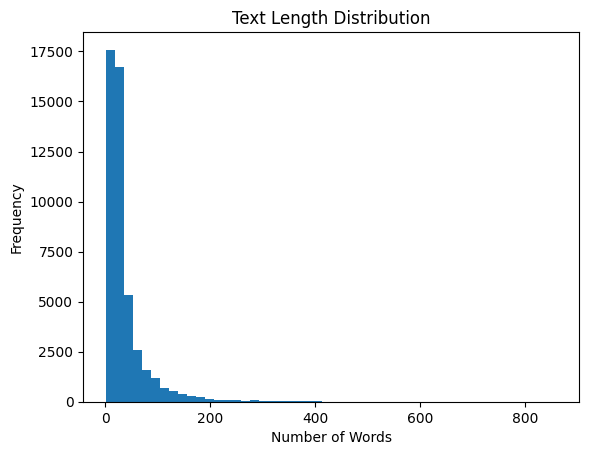

In [ ]:
df['text_length'] = df['processed_text'].apply(lambda x: len(x.split()))

df['text_length'].plot(kind='hist', bins=50)

plt.title("Text Length Distribution")
plt.xlabel("Number of Words")

plt.show()

In [ ]:
!pip install wordcloud

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

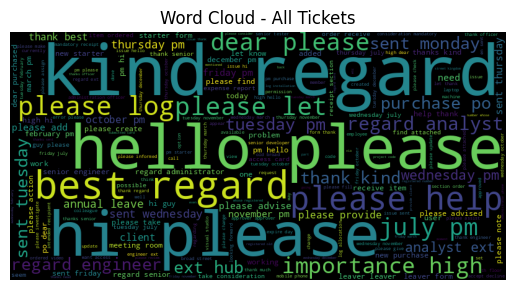

In [ ]:
# Combine all text
all_text = " ".join(df['processed_text'])

wordcloud = WordCloud(width=800, height=400).generate(all_text)

plt.figure()
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud - All Tickets")

plt.show()

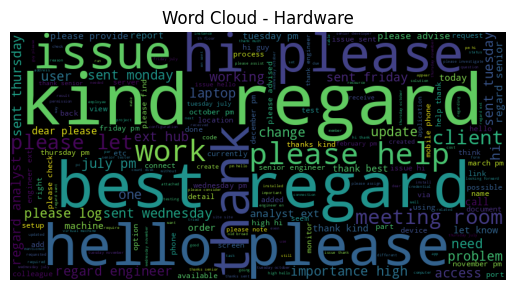

In [ ]:
category = "Hardware"  # change category

text = " ".join(df[df['Topic_group'] == category]['processed_text'])

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.figure()
plt.imshow(wordcloud)
plt.axis("off")
plt.title(f"Word Cloud - {category}")

plt.show()

Model Building & Training

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

Train Models on REAL Dataset

In [ ]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_real_tfidf, y_train)

# Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_real_tfidf, y_train)

# SVM
svm_model = LinearSVC()
svm_model.fit(X_train_real_tfidf, y_train)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train_real_tfidf, y_train)

RandomForestClassifier()

Train Models on SYNTHETIC Dataset

In [ ]:
lr_model_synth = LogisticRegression(max_iter=1000)
lr_model_synth.fit(X_train_synth_tfidf, synthetic_labels)

nb_model_synth = MultinomialNB()
nb_model_synth.fit(X_train_synth_tfidf, synthetic_labels)

svm_model_synth = LinearSVC()
svm_model_synth.fit(X_train_synth_tfidf, synthetic_labels)

rf_model_synth = RandomForestClassifier(n_estimators=100)
rf_model_synth.fit(X_train_synth_tfidf, synthetic_labels)

RandomForestClassifier()

Train Models on COMBINED Dataset

In [ ]:
lr_model_comb = LogisticRegression(max_iter=1000)
lr_model_comb.fit(X_train_combined_tfidf, combined_labels)

nb_model_comb = MultinomialNB()
nb_model_comb.fit(X_train_combined_tfidf, combined_labels)

svm_model_comb = LinearSVC()
svm_model_comb.fit(X_train_combined_tfidf, combined_labels)

rf_model_comb = RandomForestClassifier(n_estimators=100)
rf_model_comb.fit(X_train_combined_tfidf, combined_labels)

RandomForestClassifier()

Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Evaluate REAL Dataset Models

In [ ]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)

    print(f"\n🔹 {name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

In [ ]:
# Evaluate models trained on REAL data
evaluate_model(lr_model, X_test_tfidf, y_test, "Logistic Regression (Real)")
evaluate_model(nb_model, X_test_tfidf, y_test, "Naive Bayes (Real)")
evaluate_model(svm_model, X_test_tfidf, y_test, "SVM (Real)")
evaluate_model(rf_model, X_test_tfidf, y_test, "Random Forest (Real)")


🔹 Logistic Regression (Real)
Accuracy: 0.8536789297658863

Classification Report:
                        precision    recall  f1-score   support

               Access       0.91      0.87      0.89      1425
Administrative rights       0.88      0.63      0.73       352
           HR Support       0.86      0.87      0.87      2183
             Hardware       0.79      0.89      0.84      2724
     Internal Project       0.93      0.82      0.87       424
        Miscellaneous       0.82      0.82      0.82      1412
             Purchase       0.97      0.87      0.92       493
              Storage       0.93      0.82      0.87       555

             accuracy                           0.85      9568
            macro avg       0.89      0.82      0.85      9568
         weighted avg       0.86      0.85      0.85      9568


🔹 Naive Bayes (Real)
Accuracy: 0.7849080267558528

Classification Report:
                        precision    recall  f1-score   support

               Ac

Evaluate SYNTHETIC Dataset Models

In [ ]:
evaluate_model(lr_model_synth, X_test_tfidf, y_test, "Logistic Regression (Synthetic)")
evaluate_model(nb_model_synth, X_test_tfidf, y_test, "Naive Bayes (Synthetic)")
evaluate_model(svm_model_synth, X_test_tfidf, y_test, "SVM (Synthetic)")
evaluate_model(rf_model_synth, X_test_tfidf, y_test, "Random Forest (Synthetic)")


🔹 Logistic Regression (Synthetic)
Accuracy: 0.854933110367893

Classification Report:
                        precision    recall  f1-score   support

               Access       0.90      0.88      0.89      1425
Administrative rights       0.90      0.63      0.74       352
           HR Support       0.86      0.87      0.87      2183
             Hardware       0.80      0.89      0.84      2724
     Internal Project       0.91      0.82      0.86       424
        Miscellaneous       0.83      0.82      0.82      1412
             Purchase       0.97      0.87      0.92       493
              Storage       0.93      0.83      0.88       555

             accuracy                           0.85      9568
            macro avg       0.89      0.83      0.85      9568
         weighted avg       0.86      0.85      0.85      9568


🔹 Naive Bayes (Synthetic)
Accuracy: 0.782608695652174

Classification Report:
                        precision    recall  f1-score   support

         

Evaluate COMBINED Dataset Models

In [ ]:
evaluate_model(lr_model_comb, X_test_tfidf, y_test, "Logistic Regression (Combined)")
evaluate_model(nb_model_comb, X_test_tfidf, y_test, "Naive Bayes (Combined)")
evaluate_model(svm_model_comb, X_test_tfidf, y_test, "SVM (Combined)")
evaluate_model(rf_model_comb, X_test_tfidf, y_test, "Random Forest (Combined)")


🔹 Logistic Regression (Combined)
Accuracy: 0.8569188963210702

Classification Report:
                        precision    recall  f1-score   support

               Access       0.91      0.88      0.89      1425
Administrative rights       0.87      0.65      0.75       352
           HR Support       0.86      0.87      0.86      2183
             Hardware       0.81      0.88      0.84      2724
     Internal Project       0.90      0.84      0.87       424
        Miscellaneous       0.83      0.82      0.83      1412
             Purchase       0.97      0.87      0.92       493
              Storage       0.93      0.85      0.89       555

             accuracy                           0.86      9568
            macro avg       0.88      0.83      0.86      9568
         weighted avg       0.86      0.86      0.86      9568


🔹 Naive Bayes (Combined)
Accuracy: 0.7861622073578596

Classification Report:
                        precision    recall  f1-score   support

         

Confusion Matrix Visualization

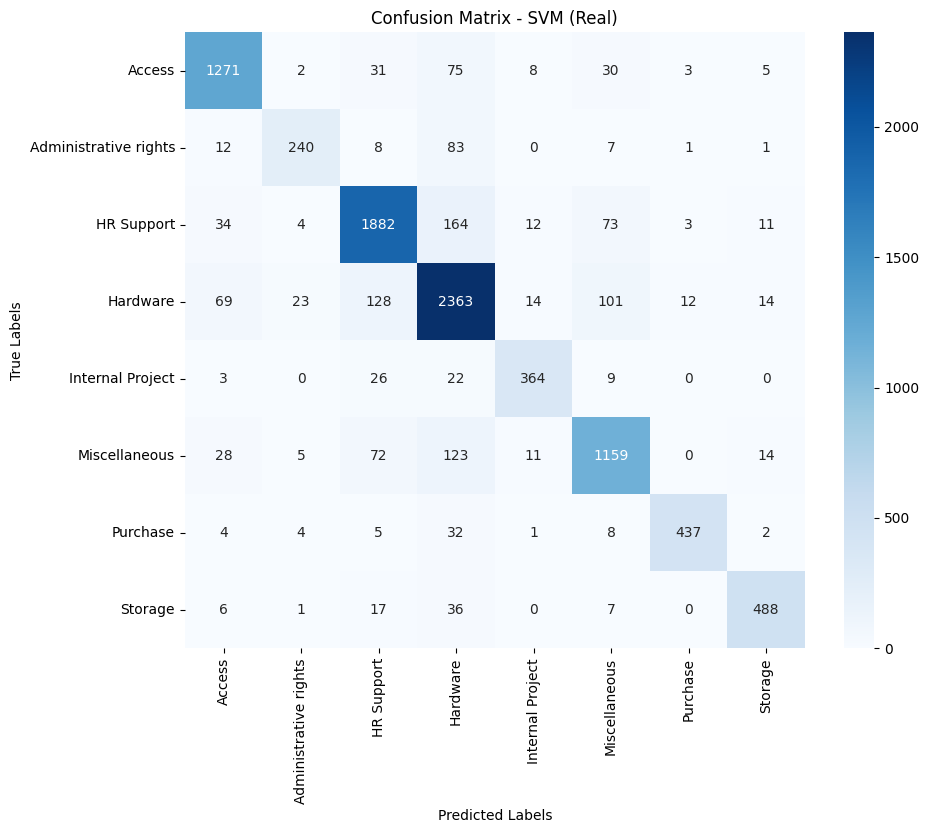

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Choose best model (SVM Real)
y_pred = svm_model.predict(X_test_tfidf)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=svm_model.classes_,
            yticklabels=svm_model.classes_)

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - SVM (Real)")
plt.show()

LSTM Model (Deep Learning)

In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
# Define tokenizer
tokenizer = Tokenizer(num_words=5000)

# Fit on training text
tokenizer.fit_on_texts(X_train)

# Convert text → sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [ ]:
max_len = 100  # fixed length

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

In [ ]:
model = Sequential()

model.add(Embedding(input_dim=5000, output_dim=128, input_length=max_len))
model.add(LSTM(64, return_sequences=False))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dense(len(le.classes_), activation='softmax'))

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train_pad,
    y_train_enc,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
539/539 ━━━━━━━━━━━━━━━━━━━━ 79s 132ms/step - accuracy: 0.2783 - loss: 1.8448 - val_accuracy: 0.2859 - val_loss: 1.8206
Epoch 2/5
539/539 ━━━━━━━━━━━━━━━━━━━━ 67s 124ms/step - accuracy: 0.2918 - loss: 1.7996 - val_accuracy: 0.2898 - val_loss: 1.8150
Epoch 3/5
539/539 ━━━━━━━━━━━━━━━━━━━━ 64s 119ms/step - accuracy: 0.3761 - loss: 1.6734 - val_accuracy: 0.5498 - val_loss: 1.2935
Epoch 4/5
539/539 ━━━━━━━━━━━━━━━━━━━━ 65s 121ms/step - accuracy: 0.6335 - loss: 1.0769 - val_accuracy: 0.7353 - val_loss: 0.8301
Epoch 5/5
539/539 ━━━━━━━━━━━━━━━━━━━━ 66s 122ms/step - accuracy: 0.7843 - loss: 0.6956 - val_accuracy: 0.8257 - val_loss: 0.5582


In [ ]:
loss, accuracy = model.evaluate(X_test_pad, y_test_enc)

print("LSTM Accuracy:", accuracy)

299/299 ━━━━━━━━━━━━━━━━━━━━ 15s 51ms/step - accuracy: 0.8204 - loss: 0.5693
LSTM Accuracy: 0.8204431533813477


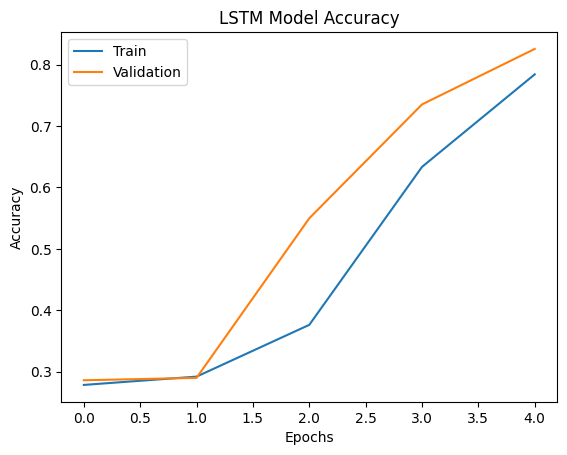

In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("LSTM Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

plt.show()

In [ ]:
import numpy as np

# Predict probabilities
y_pred_probs = model.predict(X_test_pad)

# Convert to class labels
y_pred_lstm = np.argmax(y_pred_probs, axis=1)

299/299 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step


In [ ]:
from sklearn.metrics import confusion_matrix

cm_lstm = confusion_matrix(y_test_enc, y_pred_lstm)

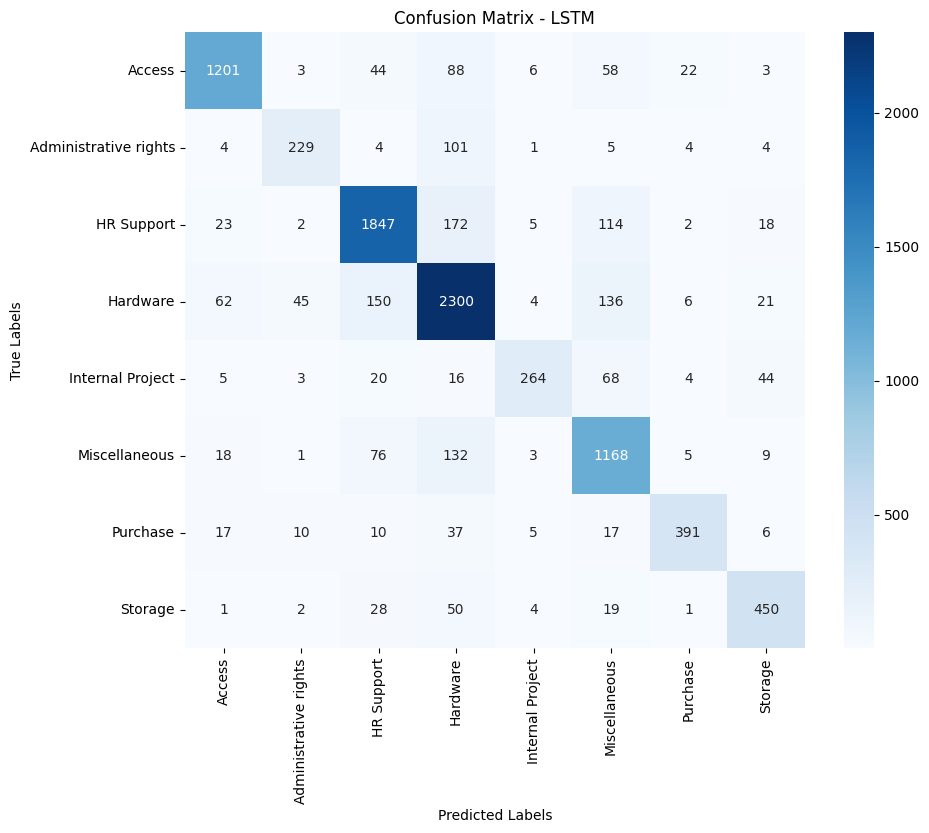

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - LSTM")

plt.show()

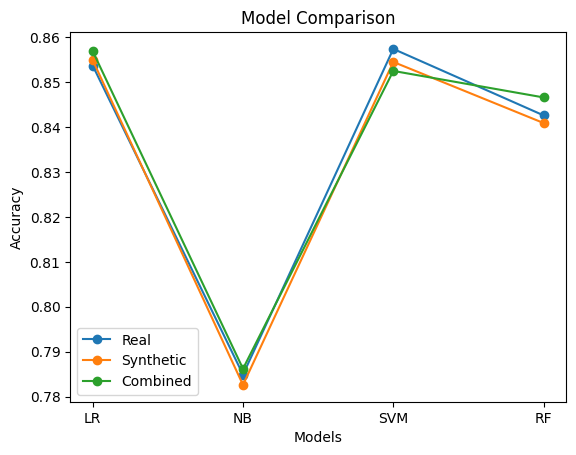

In [ ]:
models = ['LR', 'NB', 'SVM', 'RF']
real_acc = [0.8537, 0.7849, 0.8574, 0.8426]
synthetic_acc = [0.8549, 0.7826, 0.8545, 0.8409]
combined_acc = [0.8569, 0.7862, 0.8525, 0.8466]

x = range(len(models))

plt.figure()
plt.plot(x, real_acc, marker='o', label='Real')
plt.plot(x, synthetic_acc, marker='o', label='Synthetic')
plt.plot(x, combined_acc, marker='o', label='Combined')

plt.xticks(x, models)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.legend()
plt.show()